# 🍱 Simulasi Sistem Antrian Makanan di Kantin Kampus

**Metode:** Agent-Based Modeling (ABM) berbasis langkah waktu (time-step)  
**Tujuan:** Membandingkan performa sistem antrian kantin pada kondisi **Jam Biasa** vs **Jam Makan Siang (Rush Hour)** dengan **Monte Carlo 2000 iterasi** (1000 per skenario)  

---
### 📌 Latar Belakang
Kantin kampus sering mengalami penumpukan antrian saat jam makan siang (11.30–13.00).  
Simulasi ini bertujuan menjawab pertanyaan:
- Berapa lama rata-rata mahasiswa menunggu di antrian?
- Apakah jumlah kasir yang tersedia sudah cukup?
- Apa perbedaan performa antara jam biasa dan rush hour?

### 📐 Asumsi Model
| Parameter | Nilai |
|---|---|
| Durasi simulasi | 120 menit (2 jam operasional) |
| Jumlah kasir | 2 kasir |
| Rata-rata waktu pelayanan | 3 menit/mahasiswa |
| Jam biasa: jeda kedatangan | rata-rata setiap 5 menit |
| Rush hour: jeda kedatangan | rata-rata setiap 2 menit |

---
## 📦 CELL 1 — Setup Environment

### Penjelasan Algoritma:
Sebelum simulasi bisa dijalankan, kita perlu **menyiapkan semua alat (library)** yang dibutuhkan.

| Library | Fungsi |
|---|---|
| `numpy` | Membangkitkan angka acak sesuai distribusi statistik (Poisson, normal) |
| `pandas` | Menyimpan dan mengolah hasil simulasi dalam bentuk tabel |
| `matplotlib & seaborn` | Membuat grafik dan visualisasi hasil simulasi |

**Kenapa ABM time-step?**  
ABM memodelkan setiap mahasiswa sebagai agen dengan state (datang, menunggu, dilayani), lalu sistem berjalan per menit (time-step) sehingga perubahan antrian bisa diamati secara bertahap.

In [1]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn ipython -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\MSI\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# =========================================================
# CELL 1: SETUP ENVIRONMENT
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# Konfigurasi tampilan grafik agar tajam dan rapi
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set(style="whitegrid", palette="muted")

print("✅ Semua library berhasil dimuat. Siap menjalankan simulasi!")

✅ Semua library berhasil dimuat. Siap menjalankan simulasi!


---
## ⚙️ CELL 2 — Parameter Global & Logika Agen (ABM)

### Penjelasan Algoritma:

Cell ini mendefinisikan **parameter sistem** dan **logika inti simulasi ABM** berbasis time-step (per menit).

#### 🔧 Parameter Global
Semua angka yang mengendalikan simulasi dikumpulkan di satu tempat agar mudah diubah:
- `SIM_TIME = 120` → simulasi berjalan selama 120 menit (2 jam)
- `JUMLAH_KASIR = 2` → ada 2 kasir yang bisa melayani sekaligus
- `AVG_SERVICE = 3` → rata-rata 3 menit untuk melayani 1 mahasiswa
- `STD_SERVICE = 0.5` → variasi waktu ±0.5 menit (tidak selalu tepat 3 menit)
- `INTERVAL_BIASA = 5` → rata-rata jeda kedatangan 5 menit (Jam Biasa)
- `INTERVAL_RUSH = 2` → rata-rata jeda kedatangan 2 menit (Rush Hour)

#### 👤 Agen Mahasiswa — State & Perilaku
Setiap mahasiswa adalah **agen** dengan state:
- `arrival_time` (datang)
- `start_time` (mulai dilayani)
- `service_time` (durasi pelayanan)

Agen masuk ke **queue**, lalu berpindah state saat kasir tersedia.

```
[MASUK KANTIN] → [CEK KASIR] → [ANTRE jika kasir sibuk] → [DILAYANI] → [SELESAI]
```

1. Catat `arrival_time` saat mahasiswa masuk
2. Mahasiswa masuk antrian jika kasir penuh
3. Saat kasir kosong, mahasiswa mulai dilayani (`start_time`)
4. Durasi pelayanan diambil dari distribusi Normal
5. Data transaksi disimpan saat layanan selesai

#### 🧭 Mesin ABM (Time-Step)
Pada tiap menit simulasi:
1. **Generate kedatangan** mahasiswa dengan Poisson (λ = 1/interval)
2. **Update kasir** yang sedang melayani (kurangi sisa waktu)
3. **Assign** kasir kosong ke mahasiswa di antrian
4. **Log data** ketika layanan selesai

**Kenapa Poisson?**  
Poisson per menit adalah versi diskrit dari proses kedatangan acak dan konsisten dengan asumsi jeda kedatangan eksponensial.

In [3]:
# =========================================================
# CELL 2: PARAMETER GLOBAL & LOGIKA AGEN (ABM)
# =========================================================

# --- Parameter Global ---
SIM_TIME       = 120  # Durasi simulasi: 120 menit (2 jam)
JUMLAH_KASIR   = 2    # Jumlah kasir yang beroperasi
AVG_SERVICE    = 3.0  # Rata-rata waktu pelayanan per mahasiswa (menit)
STD_SERVICE    = 0.5  # Standar deviasi waktu pelayanan (variasi)
INTERVAL_BIASA = 5    # Rata-rata jeda kedatangan (Jam Biasa)
INTERVAL_RUSH  = 2    # Rata-rata jeda kedatangan (Rush Hour)

# -------------------------------------------------------
# FUNGSI UTAMA: SIMULASI ABM (TIME-STEP PER MENIT)
# -------------------------------------------------------
def run_abm(interval_kedatangan, jumlah_kasir=JUMLAH_KASIR, seed=None):
    """
    Menjalankan simulasi ABM antrian kantin per menit.
    """
    rng = np.random.default_rng(seed)
    lam = 1 / interval_kedatangan
    queue = []
    kasir = [{'remaining': 0, 'current': None} for _ in range(jumlah_kasir)]
    data_store = []
    nomor = 0

    # Simulasi utama (0 s.d. SIM_TIME-1)
    for t in range(SIM_TIME):
        # 1) Kedatangan mahasiswa
        n_datang = rng.poisson(lam)
        for _ in range(n_datang):
            nomor += 1
            queue.append({'id': f'MHS-{nomor:05d}', 'arrival_time': t})

        # 2) Update kasir yang sedang melayani
        for k in kasir:
            if k['remaining'] > 0:
                k['remaining'] -= 1
                if k['remaining'] == 0 and k['current'] is not None:
                    mhs = k['current']
                    waktu_selesai = t + 1
                    data_store.append({
                        'ID_Mahasiswa'   : mhs['id'],
                        'Waktu_Datang'   : mhs['arrival_time'],
                        'Waktu_Tunggu'   : mhs['start_time'] - mhs['arrival_time'],
                        'Durasi_Layanan' : mhs['service_time'],
                        'Waktu_Selesai'  : waktu_selesai
                    })
                    k['current'] = None

        # 3) Assign kasir kosong ke antrian
        for k in kasir:
            if k['remaining'] == 0 and k['current'] is None and queue:
                mhs = queue.pop(0)
                durasi = max(1, int(round(rng.normal(AVG_SERVICE, STD_SERVICE))))
                mhs['start_time'] = t
                mhs['service_time'] = durasi
                k['current'] = mhs
                k['remaining'] = durasi

    # Selesaikan layanan yang tersisa setelah SIM_TIME
    t = SIM_TIME
    while queue or any(k['remaining'] > 0 for k in kasir):
        for k in kasir:
            if k['remaining'] > 0:
                k['remaining'] -= 1
                if k['remaining'] == 0 and k['current'] is not None:
                    mhs = k['current']
                    waktu_selesai = t + 1
                    data_store.append({
                        'ID_Mahasiswa'   : mhs['id'],
                        'Waktu_Datang'   : mhs['arrival_time'],
                        'Waktu_Tunggu'   : mhs['start_time'] - mhs['arrival_time'],
                        'Durasi_Layanan' : mhs['service_time'],
                        'Waktu_Selesai'  : waktu_selesai
                    })
                    k['current'] = None

        for k in kasir:
            if k['remaining'] == 0 and k['current'] is None and queue:
                mhs = queue.pop(0)
                durasi = max(1, int(round(rng.normal(AVG_SERVICE, STD_SERVICE))))
                mhs['start_time'] = t
                mhs['service_time'] = durasi
                k['current'] = mhs
                k['remaining'] = durasi

        t += 1

    return pd.DataFrame(data_store)

print("✅ Fungsi run_abm() siap digunakan.")

✅ Fungsi run_abm() siap digunakan.


---
## 🚀 CELL 3 — Menjalankan Simulasi ABM + Monte Carlo (2000 Iterasi)

### Penjelasan Algoritma:

Di sini kita menjalankan:
- **1 run contoh** per skenario (untuk visualisasi detail)
- **Monte Carlo 1000 iterasi** per skenario (total 2000 data)

#### Alur ABM (dilakukan berulang):

```
1. Inisialisasi agen & kasir
      ↓
2. Jalankan time-step per menit (0–120)
      ↓
3. Log data transaksi saat layanan selesai
      ↓
4. Ringkas metrik per iterasi (Monte Carlo)
```

#### Dua Skenario:

| | Skenario A (Jam Biasa) | Skenario B (Rush Hour) |
|---|---|---|
| Interval kedatangan | Poisson per menit (λ=1/5) | Poisson per menit (λ=1/2) |
| Total mahasiswa/jam | ~12 orang | ~30 orang |
| Ekspektasi antrean | Rendah | Tinggi |

**Seed Monte Carlo** dipakai agar hasil konsisten & reproducible.

In [5]:
# =========================================================
# CELL 3: MENJALANKAN SIMULASI ABM + MONTE CARLO
# =========================================================

def monte_carlo(interval_kedatangan, n_iter, skenario, seed_offset=0):
    rows = []
    for i in range(n_iter):
        df = run_abm(interval_kedatangan, seed=seed_offset + i)
        if df.empty:
            mean_wait = 0.0
            max_wait = 0.0
            std_wait = 0.0
            total = 0
            pct_wait = 0.0
        else:
            mean_wait = df['Waktu_Tunggu'].mean()
            max_wait = df['Waktu_Tunggu'].max()
            std_wait = df['Waktu_Tunggu'].std()
            total = len(df)
            pct_wait = (df['Waktu_Tunggu'] > 0).mean() * 100

        rows.append({
            'Skenario'       : skenario,
            'Iterasi'        : i + 1,
            'Rata_Tunggu'    : round(mean_wait, 2),
            'Max_Tunggu'     : round(max_wait, 2),
            'Std_Tunggu'     : round(0.0 if np.isnan(std_wait) else std_wait, 2),
            'Total_Mahasiswa': total,
            'Pct_Tunggu'     : round(pct_wait, 2)
        })
    return pd.DataFrame(rows)

# -------------------------------
# RUN CONTOH (UNTUK VISUALISASI)
# -------------------------------
print("▶ Menjalankan run contoh ABM...")
df_biasa = run_abm(INTERVAL_BIASA, seed=42)
df_rush  = run_abm(INTERVAL_RUSH, seed=99)
print(f"   ✓ Contoh Jam Biasa: {len(df_biasa)} mahasiswa")
print(f"   ✓ Contoh Rush Hour: {len(df_rush)} mahasiswa")

# --------------------------------------
# MONTE CARLO 1000 ITERASI PER SKENARIO
# --------------------------------------
N_ITER = 1000
print("▶ Menjalankan Monte Carlo 1000 iterasi per skenario...")
hasil_biasa = monte_carlo(INTERVAL_BIASA, N_ITER, 'Jam Biasa', seed_offset=1000)
hasil_rush  = monte_carlo(INTERVAL_RUSH,  N_ITER, 'Rush Hour', seed_offset=2000)
hasil_mc    = pd.concat([hasil_biasa, hasil_rush], ignore_index=True)

# Simpan hasil iterasi ke CSV
hasil_mc.to_csv('hasil_monte_carlo.csv', index=False)

print(f"\n✅ Monte Carlo selesai. Total data: {len(hasil_mc)} baris")
print("✅ Hasil iterasi disimpan sebagai 'hasil_monte_carlo.csv'")

▶ Menjalankan run contoh ABM...
   ✓ Contoh Jam Biasa: 18 mahasiswa
   ✓ Contoh Rush Hour: 51 mahasiswa
▶ Menjalankan Monte Carlo 1000 iterasi per skenario...

✅ Monte Carlo selesai. Total data: 2000 baris
✅ Hasil iterasi disimpan sebagai 'hasil_monte_carlo.csv'


---
## 📊 CELL 4 — Tabel Monte Carlo & Ringkasan Statistik

### Penjelasan Algoritma:

Setelah simulasi selesai, kita **mengekstrak insight** dari **hasil Monte Carlo 2000 iterasi**.

#### Tabel 1: Data Monte Carlo (Contoh 10 Baris)
Menampilkan sebagian kecil hasil iterasi agar format data mudah dipahami.

Kolom yang ditampilkan:
- `Rata_Tunggu` → rata-rata waktu tunggu per iterasi
- `Max_Tunggu` → waktu tunggu maksimum per iterasi
- `Std_Tunggu` → deviasi standar waktu tunggu per iterasi
- `Total_Mahasiswa` → total mahasiswa terlayani per iterasi
- `Pct_Tunggu` → persentase mahasiswa yang harus menunggu

#### Tabel 2: Ringkasan Statistik Komparatif
Merangkum performa kedua skenario menggunakan agregasi antar iterasi:
- `.mean()` → rata-rata antar iterasi
- `.max()` → nilai maksimum antar iterasi


In [6]:
# =========================================================
# CELL 4: TABEL MONTE CARLO & RINGKASAN STATISTIK
# =========================================================

# --- TABEL 1: CONTOH DATA MONTE CARLO (10 baris) ---
print("=" * 60)
print("  TABEL 1: DATA MONTE CARLO (10 BARIS CONTOH)")
print("=" * 60)
print("Catatan: 1000 iterasi Jam Biasa + 1000 iterasi Rush Hour\n")

tabel_mc = hasil_mc.head(10).copy()
display(tabel_mc.style.format({
    'Rata_Tunggu'    : '{:.2f}',
    'Max_Tunggu'     : '{:.2f}',
    'Std_Tunggu'     : '{:.2f}',
    'Pct_Tunggu'     : '{:.2f}'
}).set_caption("Monte Carlo 2000 Iterasi (Contoh 10 Baris)"))

# --- TABEL 2: RINGKASAN STATISTIK PERBANDINGAN SKENARIO ---
print("\n" + "=" * 60)
print("  TABEL 2: RINGKASAN STATISTIK MONTE CARLO")
print("=" * 60 + "\n")

def ringkas_mc(df):
    return {
        'Rata_Tunggu'     : df['Rata_Tunggu'].mean(),
        'Max_Tunggu'      : df['Max_Tunggu'].max(),
        'Total_Mahasiswa' : df['Total_Mahasiswa'].mean(),
        'Std_Tunggu'      : df['Std_Tunggu'].mean(),
        'Pct_Tunggu'      : df['Pct_Tunggu'].mean()
    }

stat_biasa = ringkas_mc(hasil_biasa)
stat_rush  = ringkas_mc(hasil_rush)

ringkasan = pd.DataFrame({
    'Indikator Performa': [
        '🕐 Rata-rata Waktu Tunggu (menit)',
        '⏱️  Waktu Tunggu Maksimum (menit)',
        '👥 Total Mahasiswa Terlayani (rata-rata)',
        '📊 Standar Deviasi Tunggu (rata-rata)',
        '⚠️  % Mahasiswa yang Harus Antri (rata-rata)',
    ],
    '🟢 Jam Biasa': [
        f"{stat_biasa['Rata_Tunggu']:.2f}",
        f"{stat_biasa['Max_Tunggu']:.2f}",
        f"{stat_biasa['Total_Mahasiswa']:.0f}",
        f"{stat_biasa['Std_Tunggu']:.2f}",
        f"{stat_biasa['Pct_Tunggu']:.1f}%",
    ],
    '🔴 Rush Hour': [
        f"{stat_rush['Rata_Tunggu']:.2f}",
        f"{stat_rush['Max_Tunggu']:.2f}",
        f"{stat_rush['Total_Mahasiswa']:.0f}",
        f"{stat_rush['Std_Tunggu']:.2f}",
        f"{stat_rush['Pct_Tunggu']:.1f}%",
    ]
})

display(ringkasan.set_index('Indikator Performa'))

  TABEL 1: DATA MONTE CARLO (10 BARIS CONTOH)
Catatan: 1000 iterasi Jam Biasa + 1000 iterasi Rush Hour



,Skenario,Iterasi,Rata_Tunggu,Max_Tunggu,Std_Tunggu,Total_Mahasiswa,Pct_Tunggu
0,Jam Biasa,1,0.11,2.00,0.46,19,5.26
1,Jam Biasa,2,0.00,0.00,0.00,19,0.00
2,Jam Biasa,3,0.00,0.00,0.00,18,0.00
3,Jam Biasa,4,0.19,2.00,0.48,27,14.81
4,Jam Biasa,5,0.12,2.00,0.43,26,7.69
5,Jam Biasa,6,0.19,3.00,0.60,31,12.90
6,Jam Biasa,7,0.00,0.00,0.00,15,0.00
7,Jam Biasa,8,0.04,1.00,0.20,25,4.00
8,Jam Biasa,9,0.04,1.00,0.21,23,4.35
9,Jam Biasa,10,0.21,3.00,0.66,24,12.50



  TABEL 2: RINGKASAN STATISTIK MONTE CARLO



,🟢 Jam Biasa,🔴 Rush Hour
Indikator Performa,,
🕐 Rata-rata Waktu Tunggu (menit),0.15,1.71
⏱️ Waktu Tunggu Maksimum (menit),7.00,26.00
👥 Total Mahasiswa Terlayani (rata-rata),24,60
📊 Standar Deviasi Tunggu (rata-rata),0.41,1.91
⚠️ % Mahasiswa yang Harus Antri (rata-rata),9.0%,52.7%


---
## 📈 CELL 5 — Visualisasi Dashboard Utama

### Penjelasan Algoritma:

Cell ini membuat **4 grafik sekaligus** dari **run contoh ABM** (bukan Monte Carlo) agar pola antrian terlihat detail.

#### Grafik 1: Boxplot — Distribusi Waktu Tunggu
Boxplot menampilkan **5 informasi sekaligus** dalam satu kotak:
- Garis tengah = Median (nilai tengah)
- Kotak = 50% data tengah (IQR)
- Garis bawah/atas = nilai minimum/maksimum (non-outlier)
- Titik di luar = Outlier (nilai ekstrem)

#### Grafik 2: Line Chart — Tren Waktu Tunggu per Urutan Kedatangan
Menunjukkan **apakah antrian memburuk** seiring berjalannya waktu. Jika garis naik terus → sistem tidak mampu menangani beban.

#### Grafik 3: Histogram — Distribusi Waktu Tunggu
Menampilkan **berapa banyak mahasiswa** yang menunggu dalam rentang waktu tertentu. Membantu melihat apakah distribusi condong ke kanan (banyak yang menunggu lama).

#### Grafik 4: Scatter Plot — Waktu Datang vs Waktu Tunggu
Menunjukkan **kapan** mahasiswa yang paling lama menunggu datang — membantu identifikasi puncak kepadatan antrian.

C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:65: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:65: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.savefig('dashboard_kantin.png', dpi=300, bbox_inches='tight')
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('dashboard_kantin.png', dpi=300, bbox_inches='tight')
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\3671184168.py:66: UserWarning: Glyph 1278

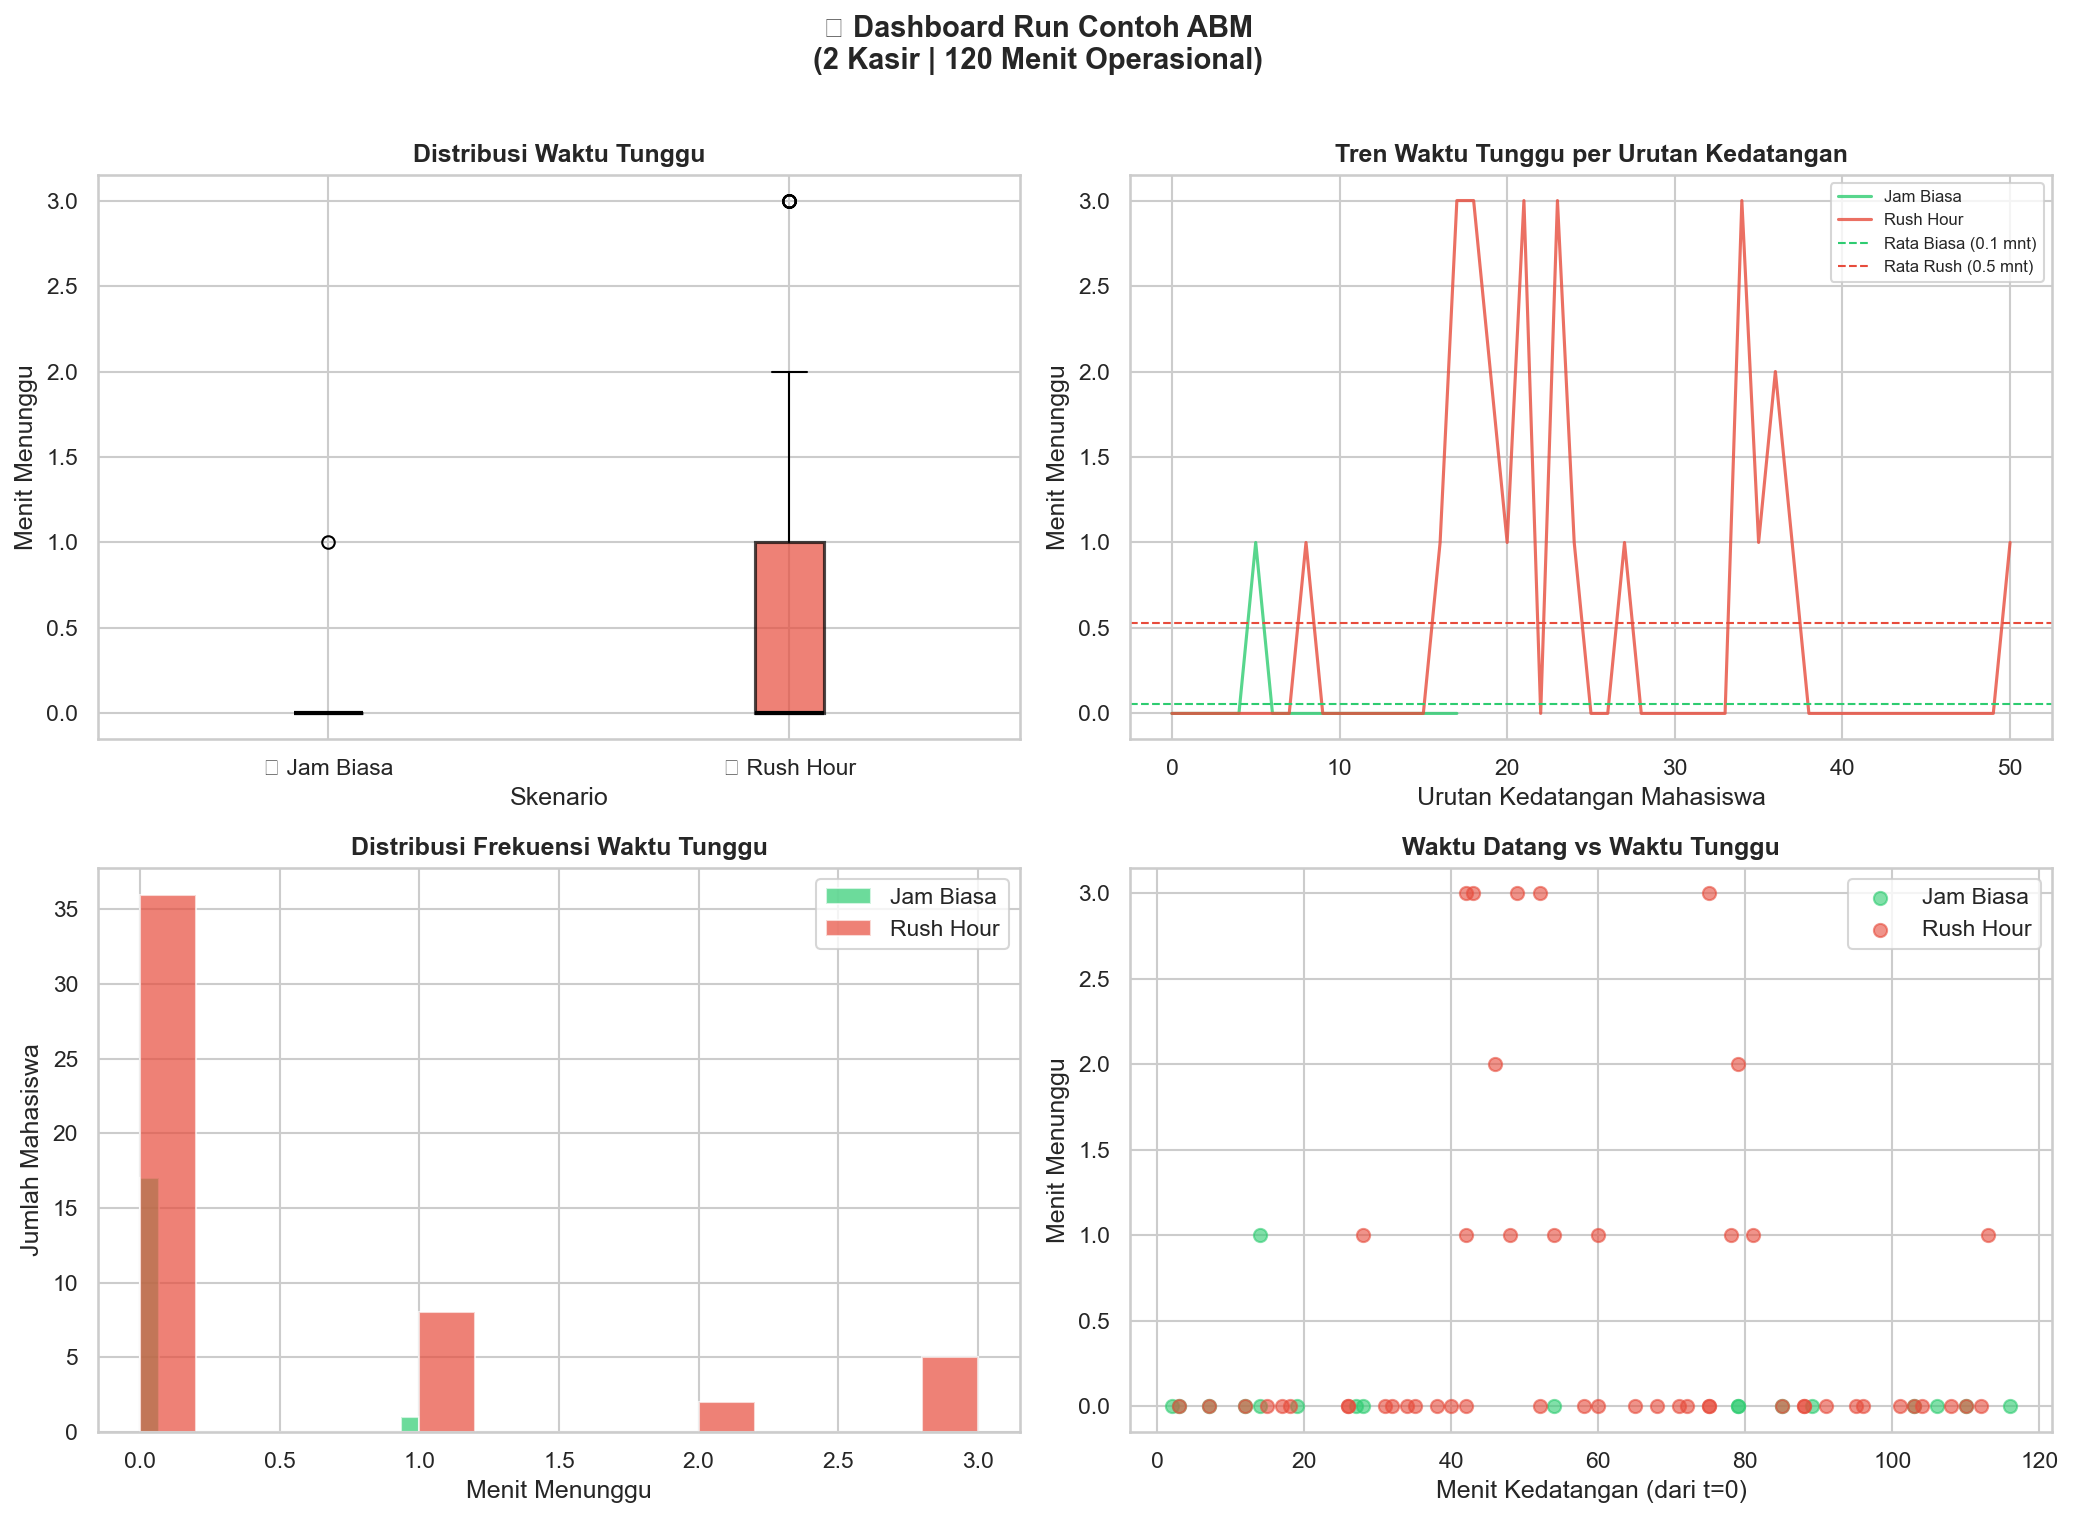

✅ Dashboard disimpan sebagai 'dashboard_kantin.png'


In [7]:
# =========================================================
# CELL 5: VISUALISASI DASHBOARD UTAMA (4 GRAFIK)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🍱 Dashboard Run Contoh ABM\n(2 Kasir | 120 Menit Operasional)',
             fontsize=14, fontweight='bold', y=1.01)

WARNA_BIASA = '#2ecc71'   # Hijau untuk Jam Biasa
WARNA_RUSH  = '#e74c3c'   # Merah untuk Rush Hour

# --- GRAFIK 1: BOXPLOT Distribusi Waktu Tunggu ---
ax1 = axes[0, 0]
data_box = [df_biasa['Waktu_Tunggu'], df_rush['Waktu_Tunggu']]
bp = ax1.boxplot(data_box, patch_artist=True, notch=False,
                 boxprops=dict(linewidth=1.5),
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(WARNA_BIASA)
bp['boxes'][1].set_facecolor(WARNA_RUSH)
for patch, alpha in zip(bp['boxes'], [0.7, 0.7]):
    patch.set_alpha(alpha)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['🟢 Jam Biasa', '🔴 Rush Hour'], fontsize=11)
ax1.set_title('Distribusi Waktu Tunggu', fontweight='bold')
ax1.set_ylabel('Menit Menunggu')
ax1.set_xlabel('Skenario')

# --- GRAFIK 2: LINE CHART Tren Waktu Tunggu ---
ax2 = axes[0, 1]
ax2.plot(range(len(df_biasa)), df_biasa['Waktu_Tunggu'],
         color=WARNA_BIASA, label='Jam Biasa', linewidth=1.5, alpha=0.8)
ax2.plot(range(len(df_rush)), df_rush['Waktu_Tunggu'],
         color=WARNA_RUSH, label='Rush Hour', linewidth=1.5, alpha=0.8)
ax2.axhline(y=df_biasa['Waktu_Tunggu'].mean(), color=WARNA_BIASA,
            linestyle='--', linewidth=1, label=f'Rata Biasa ({df_biasa["Waktu_Tunggu"].mean():.1f} mnt)')
ax2.axhline(y=df_rush['Waktu_Tunggu'].mean(), color=WARNA_RUSH,
            linestyle='--', linewidth=1, label=f'Rata Rush ({df_rush["Waktu_Tunggu"].mean():.1f} mnt)')
ax2.set_title('Tren Waktu Tunggu per Urutan Kedatangan', fontweight='bold')
ax2.set_xlabel('Urutan Kedatangan Mahasiswa')
ax2.set_ylabel('Menit Menunggu')
ax2.legend(fontsize=8)

# --- GRAFIK 3: HISTOGRAM Distribusi Waktu Tunggu ---
ax3 = axes[1, 0]
ax3.hist(df_biasa['Waktu_Tunggu'], bins=15, color=WARNA_BIASA,
         alpha=0.7, label='Jam Biasa', edgecolor='white')
ax3.hist(df_rush['Waktu_Tunggu'], bins=15, color=WARNA_RUSH,
         alpha=0.7, label='Rush Hour', edgecolor='white')
ax3.set_title('Distribusi Frekuensi Waktu Tunggu', fontweight='bold')
ax3.set_xlabel('Menit Menunggu')
ax3.set_ylabel('Jumlah Mahasiswa')
ax3.legend()

# --- GRAFIK 4: SCATTER PLOT Waktu Datang vs Waktu Tunggu ---
ax4 = axes[1, 1]
ax4.scatter(df_biasa['Waktu_Datang'], df_biasa['Waktu_Tunggu'],
            color=WARNA_BIASA, alpha=0.6, s=40, label='Jam Biasa')
ax4.scatter(df_rush['Waktu_Datang'], df_rush['Waktu_Tunggu'],
            color=WARNA_RUSH, alpha=0.6, s=40, label='Rush Hour')
ax4.set_title('Waktu Datang vs Waktu Tunggu', fontweight='bold')
ax4.set_xlabel('Menit Kedatangan (dari t=0)')
ax4.set_ylabel('Menit Menunggu')
ax4.legend()

plt.tight_layout()
plt.savefig('dashboard_kantin.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Dashboard disimpan sebagai 'dashboard_kantin.png'")

---
## 🔬 CELL 6 — Verifikasi Distribusi Input (Data Sintetik)

### Penjelasan Algoritma:

Cell ini menjawab pertanyaan penting: **"Apakah distribusi yang kita pilih sudah tepat?"**

Kita men-generate 1000 titik data sampel dan memvisualisasikannya untuk **membuktikan** bahwa:

#### 1. Distribusi Poisson — Jumlah Kedatangan per Menit
- **Formula:** `np.random.poisson(λ, 1000)` → 1000 sampel jumlah kedatangan/menit
- **Contoh:** λ = 1/2 untuk Rush Hour (rata-rata 0.5 mahasiswa per menit)
- **Ciri khas:** Histogram diskrit (0,1,2,...) dengan puncak di sekitar nilai rata-rata
- **Cocok karena:** Kedatangan per menit bersifat acak dan independen

#### 2. Distribusi Normal — Durasi Pelayanan Kasir
- **Formula:** `np.random.normal(3, 0.5, 1000)` → rata-rata 3 menit, standar deviasi 0.5
- **Ciri khas:** Histogram berbentuk lonceng simetris di sekitar nilai tengah
- **Artinya:** Mayoritas mahasiswa dilayani sekitar 3 menit, jarang yang sangat cepat atau sangat lambat
- **Cocok karena:** Ada proses standar (pesan → bayar → terima) dengan variasi kecil

Garis **KDE (Kernel Density Estimate)** di atas histogram menunjukkan kurva distribusi yang halus — berguna untuk melihat bentuk distribusi lebih jelas dari data diskrit.

C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\2716423571.py:49: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\2716423571.py:50: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  plt.savefig('verifikasi_distribusi.png', dpi=300, bbox_inches='tight')
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


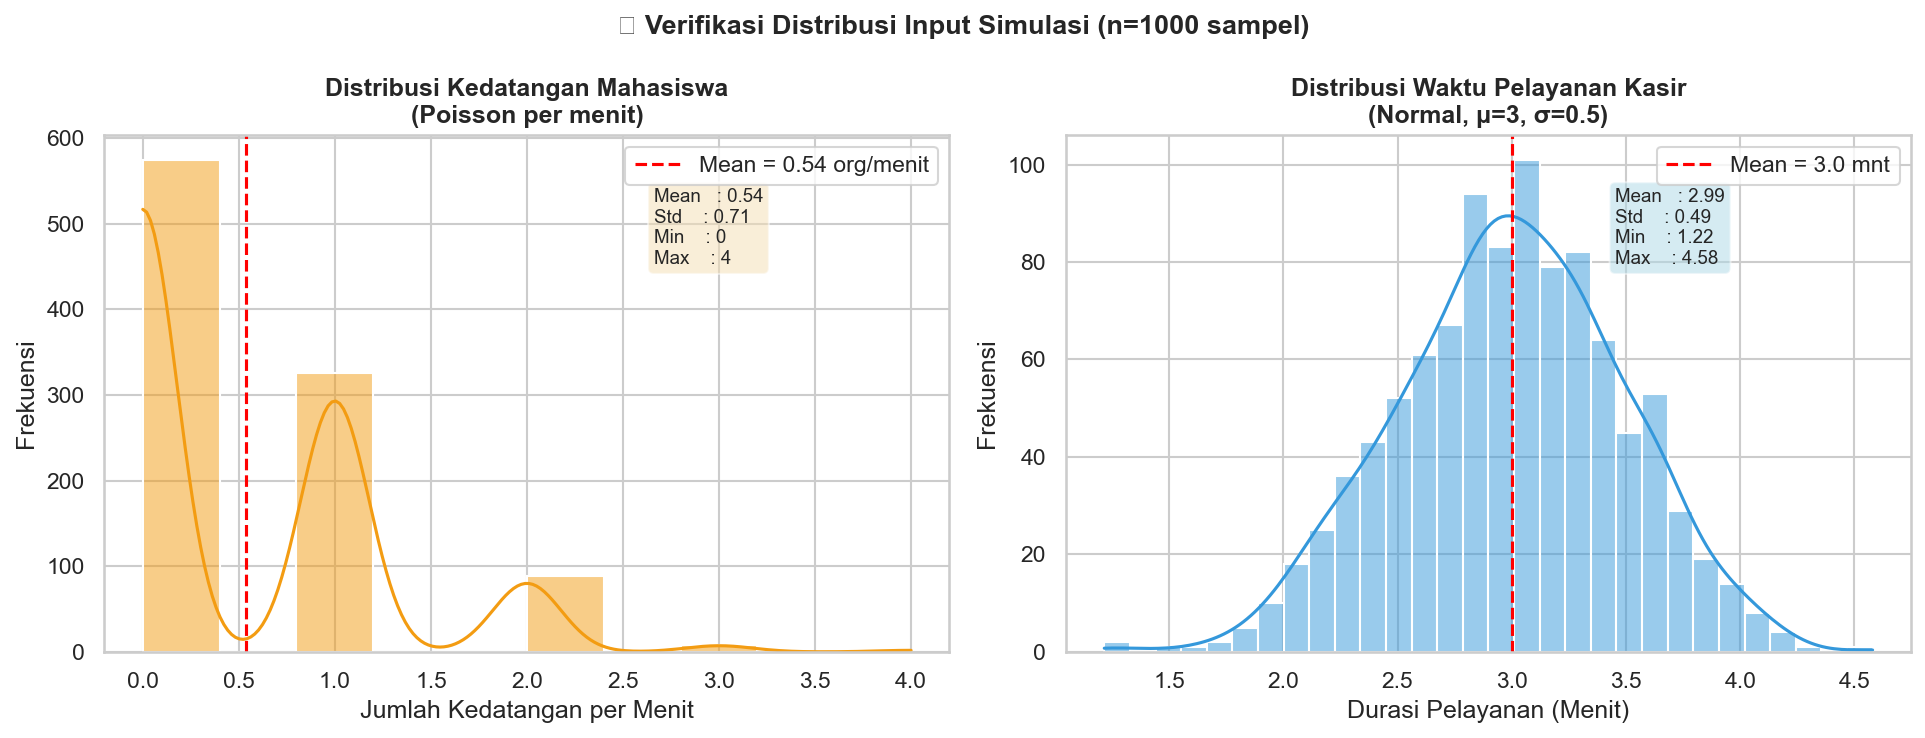

✅ Grafik verifikasi distribusi disimpan sebagai 'verifikasi_distribusi.png'


In [8]:
# =========================================================
# CELL 6: VERIFIKASI DISTRIBUSI INPUT (Data Sintetik)
# =========================================================
# Generate 1000 sampel untuk membuktikan distribusi yang dipilih sudah tepat

rng = np.random.default_rng(99)  # Seed berbeda untuk variasi visual

# 1000 sampel jumlah kedatangan per menit (Rush Hour, λ=1/2)
lam_rush = 1 / INTERVAL_RUSH
sampel_kedatangan = rng.poisson(lam_rush, 1000)

# 1000 sampel durasi pelayanan (Normal, mean=3, std=0.5)
sampel_pelayanan  = rng.normal(AVG_SERVICE, STD_SERVICE, 1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('🔬 Verifikasi Distribusi Input Simulasi (n=1000 sampel)',
             fontsize=13, fontweight='bold')

# --- Plot 1: Distribusi Kedatangan (Poisson per menit) ---
ax1 = axes[0]
sns.histplot(sampel_kedatangan, kde=True, color='#f39c12',
             bins=10, ax=ax1, edgecolor='white')
ax1.axvline(x=sampel_kedatangan.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {sampel_kedatangan.mean():.2f} org/menit')
ax1.set_title('Distribusi Kedatangan Mahasiswa\n(Poisson per menit)', fontweight='bold')
ax1.set_xlabel('Jumlah Kedatangan per Menit')
ax1.set_ylabel('Frekuensi')
ax1.legend()
ax1.text(0.65, 0.75,
         f'Mean   : {sampel_kedatangan.mean():.2f}\nStd    : {sampel_kedatangan.std():.2f}\nMin    : {sampel_kedatangan.min():.0f}\nMax    : {sampel_kedatangan.max():.0f}',
         transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Plot 2: Distribusi Pelayanan (Normal) ---
ax2 = axes[1]
sns.histplot(sampel_pelayanan, kde=True, color='#3498db',
             bins=30, ax=ax2, edgecolor='white')
ax2.axvline(x=AVG_SERVICE, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {AVG_SERVICE} mnt')
ax2.set_title('Distribusi Waktu Pelayanan Kasir\n(Normal, μ=3, σ=0.5)', fontweight='bold')
ax2.set_xlabel('Durasi Pelayanan (Menit)')
ax2.set_ylabel('Frekuensi')
ax2.legend()
ax2.text(0.65, 0.75,
         f'Mean   : {sampel_pelayanan.mean():.2f}\nStd    : {sampel_pelayanan.std():.2f}\nMin    : {sampel_pelayanan.min():.2f}\nMax    : {sampel_pelayanan.max():.2f}',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('verifikasi_distribusi.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik verifikasi distribusi disimpan sebagai 'verifikasi_distribusi.png'")

---
## 🧮 CELL 7 — Analisis Tambahan: Simulasi Multi-Kasir

### Penjelasan Algoritma:

Ini adalah analisis lanjutan yang menjawab pertanyaan praktis:
**"Berapa kasir yang ideal agar antrian tidak menumpuk saat Rush Hour?"**

#### Cara Kerja:
Kita menjalankan simulasi **berulang kali** (Monte Carlo ringan) dengan jumlah kasir berbeda (1–5), lalu membandingkan hasilnya.

```python
for jumlah_kasir in [1, 2, 3, 4, 5]:
    → Jalankan ABM rush hour sebanyak N iterasi
    → Catat rata-rata waktu tunggu
    → Bandingkan semua hasilnya
```

Grafik yang dihasilkan adalah **Elbow Chart** — titik "siku" pada grafik menunjukkan jumlah kasir optimal: tambahan kasir setelah titik itu tidak memberikan pengurangan waktu tunggu yang signifikan lagi.

#### Konsep Utilization Rate:
Selain waktu tunggu, kita juga menghitung **tingkat utilisasi kasir**:
```
Utilisasi = (Total Waktu Pelayanan) / (Jumlah Kasir × Waktu Simulasi)
```
- Utilisasi > 90% → kasir kelelahan, antrian menumpuk
- Utilisasi 70–85% → kondisi sehat dan efisien
- Utilisasi < 50% → kasir terlalu banyak, pemborosan

  1 kasir → Rata tunggu: 32.71 mnt | Utilisasi: 150.8%
  2 kasir → Rata tunggu: 1.73 mnt | Utilisasi: 75.1%
  3 kasir → Rata tunggu: 0.26 mnt | Utilisasi: 49.9%
  4 kasir → Rata tunggu: 0.06 mnt | Utilisasi: 37.3%
  5 kasir → Rata tunggu: 0.01 mnt | Utilisasi: 30.2%


C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\504260855.py:79: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\MSI\AppData\Local\Temp\ipykernel_19928\504260855.py:80: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) Arial.
  plt.savefig('analisis_kasir.png', dpi=300, bbox_inches='tight')
C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129518 (\N{ABACUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


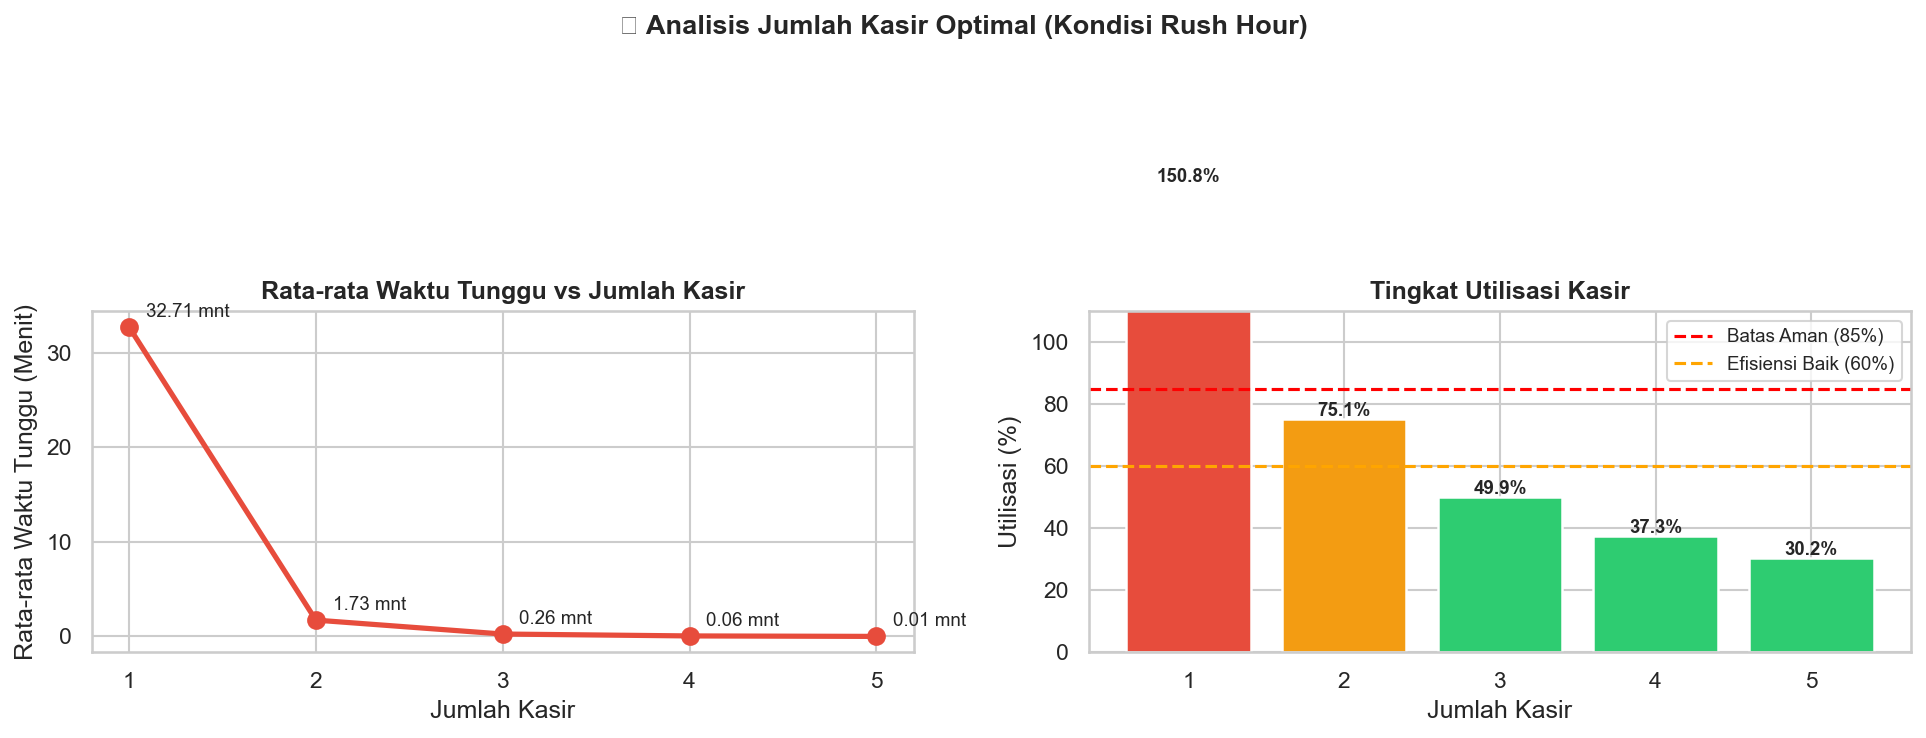


📋 Tabel Lengkap Analisis Multi-Kasir:


,Rata_Tunggu,Max_Tunggu,Total_Mahasiswa,Utilisasi_Kasir_Pct
Jumlah_Kasir,,,,
1,32.71,139.0,60,150.8
2,1.73,19.0,60,75.1
3,0.26,9.0,60,49.9
4,0.06,4.0,60,37.3
5,0.01,2.0,60,30.2



✅ Grafik disimpan sebagai 'analisis_kasir.png'


In [9]:
# =========================================================
# CELL 7: ANALISIS MULTI-KASIR — Berapa Kasir yang Ideal?
# =========================================================

N_ITER_KASIR = 200  # Monte Carlo ringan agar runtime tetap cepat

hasil_multi = []  # Menyimpan hasil tiap skenario jumlah kasir

for n_kasir in range(1, 6):  # Coba 1 sampai 5 kasir
    rata_list = []
    max_list = []
    total_list = []
    util_list = []

    for i in range(N_ITER_KASIR):
        df_temp = run_abm(INTERVAL_RUSH, jumlah_kasir=n_kasir, seed=5000 + n_kasir * 1000 + i)
        if df_temp.empty:
            rata = 0.0
            max_t = 0.0
            total = 0
            utilisasi = 0.0
        else:
            rata = df_temp['Waktu_Tunggu'].mean()
            max_t = df_temp['Waktu_Tunggu'].max()
            total = len(df_temp)
            total_waktu_layanan = df_temp['Durasi_Layanan'].sum()
            utilisasi = (total_waktu_layanan / (n_kasir * SIM_TIME)) * 100

        rata_list.append(rata)
        max_list.append(max_t)
        total_list.append(total)
        util_list.append(utilisasi)

    hasil_multi.append({
        'Jumlah_Kasir'       : n_kasir,
        'Rata_Tunggu'        : round(float(np.mean(rata_list)), 2),
        'Max_Tunggu'         : round(float(np.max(max_list)), 2),
        'Total_Mahasiswa'    : round(float(np.mean(total_list))),
        'Utilisasi_Kasir_Pct': round(float(np.mean(util_list)), 1)
    })
    print(f"  {n_kasir} kasir → Rata tunggu: {np.mean(rata_list):.2f} mnt | Utilisasi: {np.mean(util_list):.1f}%")

df_multi = pd.DataFrame(hasil_multi)

# --- Visualisasi Elbow Chart ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('🧮 Analisis Jumlah Kasir Optimal (Kondisi Rush Hour)',
             fontsize=13, fontweight='bold')

# Plot 1: Rata-rata Waktu Tunggu vs Jumlah Kasir
axes[0].plot(df_multi['Jumlah_Kasir'], df_multi['Rata_Tunggu'],
             marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
for i, row in df_multi.iterrows():
    axes[0].annotate(f"{row['Rata_Tunggu']} mnt",
                     (row['Jumlah_Kasir'], row['Rata_Tunggu']),
                     textcoords='offset points', xytext=(8, 5), fontsize=9)
axes[0].set_title('Rata-rata Waktu Tunggu vs Jumlah Kasir', fontweight='bold')
axes[0].set_xlabel('Jumlah Kasir')
axes[0].set_ylabel('Rata-rata Waktu Tunggu (Menit)')
axes[0].set_xticks(range(1, 6))

# Plot 2: Utilisasi Kasir vs Jumlah Kasir
bars = axes[1].bar(df_multi['Jumlah_Kasir'], df_multi['Utilisasi_Kasir_Pct'],
                   color=['#e74c3c' if u > 85 else '#f39c12' if u > 60 else '#2ecc71'
                          for u in df_multi['Utilisasi_Kasir_Pct']],
                   edgecolor='white', linewidth=1.2)
axes[1].axhline(y=85, color='red', linestyle='--', linewidth=1.5, label='Batas Aman (85%)')
axes[1].axhline(y=60, color='orange', linestyle='--', linewidth=1.5, label='Efisiensi Baik (60%)')
for bar, val in zip(bars, df_multi['Utilisasi_Kasir_Pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Tingkat Utilisasi Kasir', fontweight='bold')
axes[1].set_xlabel('Jumlah Kasir')
axes[1].set_ylabel('Utilisasi (%)')
axes[1].set_xticks(range(1, 6))
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('analisis_kasir.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📋 Tabel Lengkap Analisis Multi-Kasir:")
display(df_multi.set_index('Jumlah_Kasir'))
print("\n✅ Grafik disimpan sebagai 'analisis_kasir.png'")

---
## 📝 CELL 8 — Kesimpulan & Rekomendasi

### Penjelasan Algoritma:

Cell terakhir ini **membaca data hasil simulasi ABM + Monte Carlo** dan menghasilkan kesimpulan yang dinamis (angkanya menyesuaikan hasil aktual simulasi, bukan hardcode).

Teknik yang digunakan:
- **f-string formatting** → menyisipkan angka hasil simulasi ke dalam teks
- **Conditional logic** → menentukan rekomendasi berdasarkan threshold yang wajar
- **`.idxmin()`** → mencari indeks baris dengan nilai minimum (kasir optimal)

Ini menunjukkan bahwa simulasi bukan sekadar menghasilkan angka, tapi dapat dijadikan **dasar pengambilan keputusan** yang kuantitatif dan objektif.

In [10]:
# =========================================================
# CELL 8: KESIMPULAN & REKOMENDASI OTOMATIS
# =========================================================

# Ambil angka kunci dari hasil simulasi
rata_biasa   = stat_biasa['Rata_Tunggu']
rata_rush    = stat_rush['Rata_Tunggu']
max_rush     = stat_rush['Max_Tunggu']
jml_biasa    = stat_biasa['Total_Mahasiswa']
jml_rush     = stat_rush['Total_Mahasiswa']

# Cari jumlah kasir optimal (waktu tunggu paling kecil dengan utilisasi wajar)
kasir_optimal = df_multi.loc[df_multi['Utilisasi_Kasir_Pct'] <= 85, 'Jumlah_Kasir'].max()
tunggu_optimal = df_multi.loc[df_multi['Jumlah_Kasir'] == kasir_optimal, 'Rata_Tunggu'].values[0]

print("=" * 65)
print("  📝 KESIMPULAN & REKOMENDASI SIMULASI ANTRIAN KANTIN KAMPUS")
print("=" * 65)

print(f"""
🔍 TEMUAN UTAMA:

  1. PERBANDINGAN DUA KONDISI:
     • Jam Biasa  → ~{jml_biasa:.0f} mahasiswa/iterasi, rata tunggu {rata_biasa:.1f} menit
     • Rush Hour  → ~{jml_rush:.0f} mahasiswa/iterasi, rata tunggu {rata_rush:.1f} menit
     • Kenaikan waktu tunggu: {((rata_rush - rata_biasa)/max(rata_biasa, 0.01))*100:.0f}% lebih lama di Rush Hour

  2. KONDISI TERPARAH:
     • Waktu tunggu maksimal saat Rush Hour: {max_rush:.1f} menit
     • Ini terjadi akibat penumpukan antrian yang tidak sempat terurai

  3. JUMLAH KASIR OPTIMAL (berdasarkan simulasi Rush Hour):
     • Rekomendasi: {kasir_optimal} kasir
     • Rata-rata tunggu: {tunggu_optimal:.1f} menit (utilisasi kasir ≤ 85%)

💡 REKOMENDASI UNTUK PENGELOLA KANTIN:

  ✅ Tambah kasir aktif saat jam 11.30 – 13.00 (minimal {kasir_optimal} kasir)
  ✅ Pertimbangkan sistem pre-order digital untuk mengurangi waktu pelayanan
  ✅ Pisahkan antrian untuk menu cepat saji vs menu yang perlu dimasak
  ✅ Monitor panjang antrian secara real-time untuk penugasan kasir dinamis

📌 CATATAN METODOLOGI:

  • Seluruh data dibangkitkan secara sintetik menggunakan:
    - Poisson per menit untuk kedatangan mahasiswa
    - Distribusi Normal untuk durasi waktu pelayanan kasir
  • Model ini dapat dikalibrasi ulang dengan data nyata dari observasi lapangan
    untuk hasil yang lebih akurat
""")

print("=" * 65)
print("  ✅ Simulasi Selesai! Semua grafik telah disimpan.")
print("=" * 65)

  📝 KESIMPULAN & REKOMENDASI SIMULASI ANTRIAN KANTIN KAMPUS

🔍 TEMUAN UTAMA:

  1. PERBANDINGAN DUA KONDISI:
     • Jam Biasa  → ~24 mahasiswa/iterasi, rata tunggu 0.1 menit
     • Rush Hour  → ~60 mahasiswa/iterasi, rata tunggu 1.7 menit
     • Kenaikan waktu tunggu: 1067% lebih lama di Rush Hour

  2. KONDISI TERPARAH:
     • Waktu tunggu maksimal saat Rush Hour: 26.0 menit
     • Ini terjadi akibat penumpukan antrian yang tidak sempat terurai

  3. JUMLAH KASIR OPTIMAL (berdasarkan simulasi Rush Hour):
     • Rekomendasi: 5 kasir
     • Rata-rata tunggu: 0.0 menit (utilisasi kasir ≤ 85%)

💡 REKOMENDASI UNTUK PENGELOLA KANTIN:

  ✅ Tambah kasir aktif saat jam 11.30 – 13.00 (minimal 5 kasir)
  ✅ Pertimbangkan sistem pre-order digital untuk mengurangi waktu pelayanan
  ✅ Pisahkan antrian untuk menu cepat saji vs menu yang perlu dimasak
  ✅ Monitor panjang antrian secara real-time untuk penugasan kasir dinamis

📌 CATATAN METODOLOGI:

  • Seluruh data dibangkitkan secara sintetik menggun